In [1]:
import os

# Set the environment variables
os.environ["PYTORCH_NO_CUDA_MEMORY_CACHING"] = "1"
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "max_split_size_mb:25,garbage_collection_threshold:0.5,expandable_segments:True"

# Verify the settings with improved output
print("Environment Variable Settings:")
print(f"  PYTORCH_NO_CUDA_MEMORY_CACHING: {os.environ.get('PYTORCH_NO_CUDA_MEMORY_CACHING', 'Not Set')}")
print(f"  PYTORCH_CUDA_ALLOC_CONF: {os.environ.get('PYTORCH_CUDA_ALLOC_CONF', 'Not Set')}")

print("-" * 30) # add a seperator.

Environment Variable Settings:
  PYTORCH_NO_CUDA_MEMORY_CACHING: 1
  PYTORCH_CUDA_ALLOC_CONF: max_split_size_mb:25,garbage_collection_threshold:0.5,expandable_segments:True
------------------------------


In [2]:
import pickle
import yaml
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import json
import numpy as np
import geneformer
from geneformer import TranscriptomeTokenizer
import scanpy as sc
import anndata as an
from datasets import Dataset, load_from_disk
import torch
import gc
from importlib import reload

# local functions
sys.path.append("../../utils/")
import geneformer_utils as ut

In [3]:
print(f"Torch Version: {torch.__version__}")
print(f"CUDA Version: {torch.version.cuda}")

Torch Version: 2.6.0+cu124
CUDA Version: 12.4


In [4]:
device = torch.device("cuda")
print(f"CUDA device available: {torch.cuda.get_device_name(0)}")

# Get total RAM
total_memory = torch.cuda.get_device_properties(0).total_memory
print(f"Total GPU memory: {total_memory / (1024**3):.2f} GB")

# Get allocated RAM
allocated_memory = torch.cuda.memory_allocated(0)
print(f"Allocated GPU memory: {allocated_memory / (1024**3):.2f} GB")

# Get cached RAM
cached_memory = torch.cuda.memory_reserved(0)
print(f"Cached GPU memory: {cached_memory / (1024**3):.2f} GB")

CUDA device available: NVIDIA A100 80GB PCIe MIG 3g.40gb
Total GPU memory: 39.25 GB
Allocated GPU memory: 0.00 GB
Cached GPU memory: 0.00 GB


In [5]:
# break

# Model choice

In [6]:
model_str = '95m'
params_file = "../../resources/geneformer_params.yaml"

with open(params_file, 'r') as file:
    params = yaml.safe_load(file)

model = params['models'][model_str]
print(json.dumps(model, indent=2))

{
  "model_path": "/nfs/turbo/umms-indikar/shared/projects/foundation_models/geneformer/Geneformer/gf-12L-95M-i4096/",
  "gene_median": "/nfs/turbo/umms-indikar/shared/projects/foundation_models/geneformer/Geneformer/geneformer/gene_median_dictionary_gc95M.pkl",
  "token_dictionary_file": "/nfs/turbo/umms-indikar/shared/projects/foundation_models/geneformer/Geneformer/geneformer/token_dictionary_gc95M.pkl",
  "gene_mapping_file": "/nfs/turbo/umms-indikar/shared/projects/foundation_models/geneformer/Geneformer/geneformer/ensembl_mapping_dict_gc95M.pkl",
  "model_input_size": 4096,
  "special_token": true
}


# load the id mapping

In [7]:
with open(model['token_dictionary_file'], 'rb') as f:  
    tokens = pickle.load(f)

print(f"{len(tokens)=}")

len(tokens)=20275


In [8]:
with open(model['gene_mapping_file'], 'rb') as f:  
    gene_map = pickle.load(f)

print(f"{len(gene_map)=}")

len(gene_map)=173697


In [9]:
# break

# configure the input

In [10]:
adata_inpath = "/nfs/turbo/umms-indikar/shared/projects/HSC/pipeline_outputs/integrated_anndata/pseudotime.h5ad"

basename = os.path.basename(adata_inpath)
print(f"Input file ({basename}): {adata_inpath}")

output_dir = f"/nfs/turbo/umms-indikar/shared/projects/HSC/pipeline_outputs/integrated_anndata/geneformer" # NO FINAL SLASH!
print(f"Output directory: {output_dir}")

adata = sc.read_h5ad(adata_inpath)
print(f"Input adata size: {adata.shape}")

adata.obs['n_counts'] = adata.obs['nnz'].astype(int).copy()
adata.var['ensembl_id'] = adata.var['feature_id'].copy()
adata = adata[:, adata.var['ensembl_id'].isin(list(tokens.keys()))]

print(f"Output adata size: {adata.shape}")

anndata_outpath = f"{output_dir}/{basename}"
print(f"Writing file to: {anndata_outpath}")
adata.write(anndata_outpath)
print()
adata.obs.head()

Input file (pseudotime.h5ad): /nfs/turbo/umms-indikar/shared/projects/HSC/pipeline_outputs/integrated_anndata/pseudotime.h5ad
Output directory: /nfs/turbo/umms-indikar/shared/projects/HSC/pipeline_outputs/integrated_anndata/geneformer
Input adata size: (15867, 21412)
Output adata size: (15867, 14361)
Writing file to: /nfs/turbo/umms-indikar/shared/projects/HSC/pipeline_outputs/integrated_anndata/geneformer/pseudotime.h5ad



,batch,phase,n_genes_by_counts,log1p_n_genes_by_counts,total_counts,log1p_total_counts,pct_counts_in_top_50_genes,pct_counts_in_top_100_genes,pct_counts_in_top_200_genes,pct_counts_in_top_500_genes,...,dpt_groups,dpt_order,dpt_order_indices,G1_pseudotime,G1_order,G2M_pseudotime,G2M_order,mean_pseudotime,mean_order,nnz
AAACCCAAGGTTACCT-1,hsc,G1,3679,8.210668,11202.0,9.323937,27.932512,37.752187,47.491519,60.382075,...,0,0,0,0.804527,0,0.813038,0,0.808782,0.0,3679
AAACCCAAGTTGAAGT-1,hsc,G1,3987,8.291045,10579.0,9.266721,24.766046,32.867001,40.835618,53.313168,...,0,7688,6161,0.919730,7688,0.924270,7688,0.922000,7688.0,3987
AAACCCAAGTTGTCGT-1,hsc,S,2585,7.857868,6735.0,8.815222,28.537491,37.371938,48.136600,63.533779,...,3,9322,6160,0.478926,9764,0.049480,9322,0.264203,9543.0,2585
AAACCCACAGAAGCGT-1,hsc,G1,2358,7.765993,5416.0,8.597297,24.686115,34.785820,45.217873,60.672083,...,4,15237,6159,0.087955,15063,0.503773,15237,0.295864,15150.0,2358
AAACCCACAGGAGGTT-1,hsc,G1,4997,8.516793,21937.0,9.995976,31.845740,40.552491,50.152710,63.440762,...,0,6684,6158,0.790149,6684,0.784025,6684,0.787087,6684.0,4995


# How many cells are truncated?

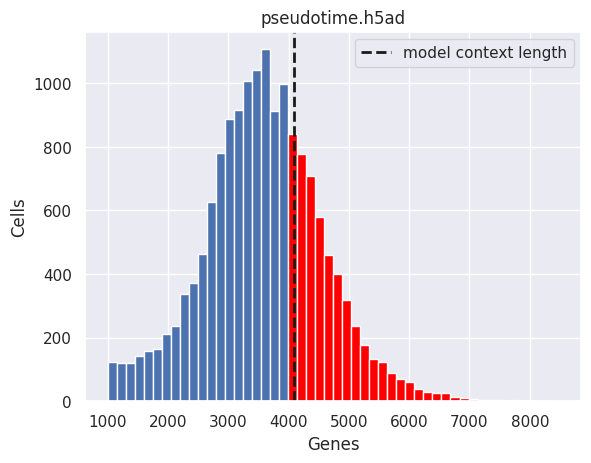

Percentage of cells that are truncated: 28.73%


In [11]:
# Create the histogram plot
counts, bins, patches = plt.hist(adata.obs['n_counts'], bins=50)

# Draw the vertical line
vline_x = model['model_input_size']
plt.axvline(x=vline_x, lw=2, c='k', ls="--", label="model context length")

# Color the bars to the right of the vertical line red
for i in range(len(patches)):
    if bins[i+1] > vline_x:
        patches[i].set_facecolor('red')

plt.xlabel("Genes")
plt.ylabel("Cells")
plt.legend()
plt.title(basename)
plt.show()

# Calculate the percentage of observations beyond the red line
beyond_vline = adata.obs['n_counts'][adata.obs['n_counts'] > vline_x]
percentage = (len(beyond_vline) / len(adata.obs['n_counts'])) * 100

print(f"Percentage of cells that are truncated: {percentage:.2f}%")

# Tokenization

In [12]:
gene_median = model['gene_median']
token_dictionary_file = model['token_dictionary_file']
gene_mapping_file = model['gene_mapping_file']

columns = [
    'batch', 'phase', 'n_counts', 'mean_pseudotime', 
    'mean_order', 'nnz', 'S_score', 'G2M_score',
    'cluster_str', 
]

custom_attr_name_dict = {
    x: x for x in columns
}

tk = TranscriptomeTokenizer(
    custom_attr_name_dict=custom_attr_name_dict, 
    chunk_size=512,
    model_input_size=model['model_input_size'], # 2048 or 4096
    special_token=model['special_token'],
    collapse_gene_ids=True,
    nproc=8,
    gene_median_file=gene_median,
    token_dictionary_file=token_dictionary_file,
    gene_mapping_file=gene_mapping_file,
)

print('ready!')

ready!


In [13]:
torch.cuda.empty_cache()
basename_no_ext = basename.split(".")[0]
token_output_path = os.path.join(output_dir, f"{basename_no_ext}.dataset")

if os.path.exists(token_output_path):
    raise FileExistsError(f"File already exists: {token_output_path}")

print(f"Saving tokenized data to: {token_output_path}")
tokenized_cells, cell_metadata = tk.tokenize_anndata(
    anndata_outpath, # the configured anndata object path
    target_sum=10000,
)

tokenized_dataset = tk.create_dataset(
    tokenized_cells,
    cell_metadata,
)

tokenized_dataset.save_to_disk(str(token_output_path))
print('done!')

Saving tokenized data to: /nfs/turbo/umms-indikar/shared/projects/HSC/pipeline_outputs/integrated_anndata/geneformer/pseudotime.dataset
/nfs/turbo/umms-indikar/shared/projects/HSC/pipeline_outputs/integrated_anndata/geneformer/pseudotime.h5ad has no column attribute 'filter_pass'; tokenizing all cells.
Creating dataset.
done!


<!-- break -->

# Model Definition

In [14]:
# load and reverse the token mapping
token_dict = ut.load_pickle(token_dictionary_file)
token_dict = {v: k for k, v in token_dict.items()} # WHY?
print(f"{len(token_dict)=}")

model_obj = ut.load_model(model['model_path'])
# print(model_obj)
print('ready!')

len(token_dict)=20275
ready!


# Cell Emebdddings

In [15]:
torch.cuda.empty_cache()

"""
FULL SET OF DATA FOR CELL EMBEDDINGS
"""
df = ut.load_data_as_dataframe(token_output_path)
data = Dataset.from_pandas(df)
print(f"{df.shape=}")
df.head(2)

df.shape=(15867, 11)


,input_ids,batch,phase,n_counts,mean_pseudotime,mean_order,nnz,S_score,G2M_score,cluster_str,length
0,"[2, 10172, 10171, 2839, 2706, 15305, 14422, 27...",hsc,G1,3679,0.808782,0.0,3679,-0.005952,-1.192717,C3,3436
1,"[2, 17488, 17862, 15445, 13841, 17068, 6943, 6...",hsc,G1,3987,0.922000,7688.0,3987,-0.198413,-1.039894,C3,3679


In [16]:
torch.cuda.empty_cache()

emb_output_path = f"{output_dir}/{basename_no_ext}_cell_embeddings.h5ad"
print(f"Saving cell embeddings to: {emb_output_path}")

edata = ut.extract_cell_embeddings(
    model=model_obj,
    data=data,
    token_gene_dict=token_dict,
)

edata

CLS token present in token dictionary, excluding from average.
EOS token present in token dictionary, excluding from average.


Saving cell embeddings to: /nfs/turbo/umms-indikar/shared/projects/HSC/pipeline_outputs/integrated_anndata/geneformer/pseudotime_cell_embeddings.h5ad


  0%|          | 0/1587 [00:00<?, ?it/s]

AnnData object with n_obs × n_vars = 15867 × 512
    obs: 'input_ids', 'batch', 'phase', 'n_counts', 'mean_pseudotime', 'mean_order', 'nnz', 'S_score', 'G2M_score', 'cluster_str', 'length'

In [21]:
%%time

# Add some nice metadata
edata.obsm['X_draw_graph_fa'] = adata.obsm['X_draw_graph_fa'].copy()
edata.obsm['X_pca_harmony'] = adata.obsm['X_pca_harmony'].copy()
edata.uns['gene_df'] = adata.to_df(layer='log_norm').copy()

# save to disk
edata.write(emb_output_path)

edata


CPU times: user 12.3 s, sys: 2.96 s, total: 15.3 s
Wall time: 20.1 s


AnnData object with n_obs × n_vars = 15867 × 512
    obs: 'input_ids', 'batch', 'phase', 'n_counts', 'mean_pseudotime', 'mean_order', 'nnz', 'S_score', 'G2M_score', 'cluster_str', 'length'
    uns: 'gene_df'
    obsm: 'X_draw_graph_fa', 'X_pca_harmony'

In [22]:
torch.cuda.empty_cache()
gc.collect()    

2729

In [23]:
device = torch.device("cuda")
print(f"CUDA device available: {torch.cuda.get_device_name(0)}")

# Get total RAM
total_memory = torch.cuda.get_device_properties(0).total_memory
print(f"Total GPU memory: {total_memory / (1024**3):.2f} GB")

# Get allocated RAM
allocated_memory = torch.cuda.memory_allocated(0)
print(f"Allocated GPU memory: {allocated_memory / (1024**3):.2f} GB")

# Get cached RAM
cached_memory = torch.cuda.memory_reserved(0)
print(f"Cached GPU memory: {cached_memory / (1024**3):.2f} GB")

CUDA device available: NVIDIA A100 80GB PCIe MIG 3g.40gb
Total GPU memory: 39.25 GB
Allocated GPU memory: 0.00 GB
Cached GPU memory: 0.00 GB


In [20]:
break

SyntaxError: 'break' outside loop (668683560.py, line 1)

# get gene names

In [ ]:
# take the first gene name for each gene id
gdf = pd.DataFrame.from_dict(
    ut.load_pickle(gene_mapping_file),
    orient='index',
    columns=['gene_id']
).reset_index(names='gene_name')

gdf = gdf[~gdf['gene_name'].str.startswith('ENSG0')]
gdf = gdf.drop_duplicates(subset='gene_id', keep='first')
print(f"{gdf.shape=}")
gdf.tail()

# Gene embeddings

In [ ]:
torch.cuda.empty_cache()

"""
SAMPLE SET OF DATA FOR CELL EMBEDDINGS
"""
df = ut.load_data_as_dataframe(
    token_output_path,
)
data = Dataset.from_pandas(df)
print(f"{df.shape=}")
df.head(2)

In [ ]:
reload(ut)
torch.cuda.empty_cache()
gc.collect()

emb_output_path = f"{output_dir}/{basename_no_ext}_gene_embeddings.h5ad"
print(f"Saving cell embeddings to: {emb_output_path}")

edata = ut.extract_gene_embeddings_batched(
    model=model_obj,
    data=data,
    token_gene_dict=token_dict,
    verbose=True,
)

edata

# aggregate
edata = sc.get.aggregate(
    edata,
    by='gene_id',
    func='mean',
    axis='obs',   
)

# mem management
torch.cuda.empty_cache()
gc.collect()    

# merge in the gene names
print(f"{edata.obs.shape=}")
edata.obs = pd.merge(
    edata.obs, gdf, 
    how='left',
    left_on='gene_id',
    right_on='gene_id'
)
print(f"{edata.obs.shape=}")
sc.logging.print_memory_usage()

# save to disk
edata.write(emb_output_path)
edata

In [ ]:
edata.obs.head()

In [ ]:
break